In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/Users/josephmiddleton/Documents/Projects/ab-testing-market-analysis/data/marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [6]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(588101, 7)
Unnamed: 0       int64
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


In [7]:
df = df.drop(columns=['Unnamed: 0'])
df['test group'].value_counts()
df['test group'].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

In [8]:
conversion_by_group = df.groupby('test group')['converted'].mean()
conversion_by_group

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

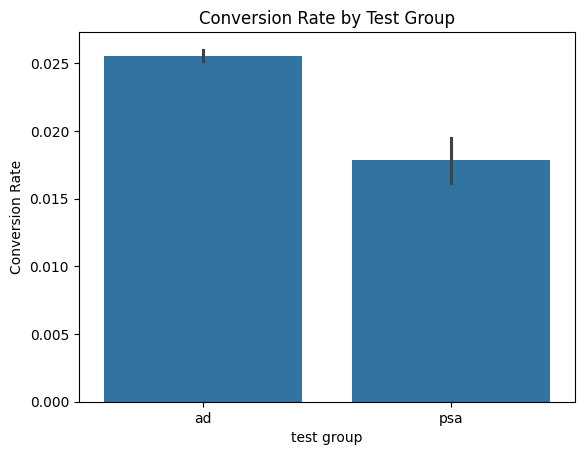

In [9]:
sns.barplot(data=df, x='test group', y='converted')
plt.title('Conversion Rate by Test Group')
plt.ylabel('Conversion Rate')
plt.show()

In [10]:
from statsmodels.stats.proportion import proportions_ztest

# counts of conversions and total observations per group
conversions = df.groupby('test group')['converted'].sum()
totals = df.groupby('test group')['converted'].count()

print(conversions)
print(totals)

# order: [ad, psa]
count = [conversions['ad'], conversions['psa']]
nobs = [totals['ad'], totals['psa']]

z_stat, p_value = proportions_ztest(count, nobs)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")

test group
ad     14423
psa      420
Name: converted, dtype: int64
test group
ad     564577
psa     23524
Name: converted, dtype: int64
Z-statistic: 7.3701
P-value: 0.0000000000


In [11]:
from statsmodels.stats.proportion import confint_proportions_2indep

# confidence interval on the difference in proportions
ci_low, ci_upp = confint_proportions_2indep(
    count1=conversions['ad'], nobs1=totals['ad'],
    count2=conversions['psa'], nobs2=totals['psa'],
    method='wald'
)

diff = conversion_by_group['ad'] - conversion_by_group['psa']
relative_lift = diff / conversion_by_group['psa']

print(f"Absolute difference in conversion: {diff:.4f} ({diff*100:.2f} percentage points)")
print(f"Relative lift: {relative_lift*100:.1f}%")
print(f"95% CI for absolute difference: ({ci_low:.4f}, {ci_upp:.4f})")


Absolute difference in conversion: 0.0077 (0.77 percentage points)
Relative lift: 43.1%
95% CI for absolute difference: (0.0060, 0.0094)


In [12]:
df.groupby('test group')['total ads'].describe()

,count,mean,std,min,25%,50%,75%,max
test group,,,,,,,,
ad,564577.0,24.823365,43.750456,1.0,4.0,13.0,27.0,2065.0
psa,23524.0,24.761138,42.860720,1.0,4.0,12.0,26.0,907.0


In [13]:
import statsmodels.formula.api as smf

# convert test group to a clean binary indicator
df['is_ad'] = (df['test group'] == 'ad').astype(int)
df['converted_num'] = df['converted'].astype(int)

model = smf.logit(
    'converted_num ~ is_ad + total_ads + C(most_ads_day)',
    data=df.rename(columns={'total ads': 'total_ads', 'most ads day': 'most_ads_day'})
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.108620
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          converted_num   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588092
Method:                           MLE   Df Model:                            8
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.07778
Time:                        14:58:00   Log-Likelihood:                -63879.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -4.6326      0.056    -83.206      0.000

In [14]:
import numpy as np
odds_ratio = np.exp(model.params['is_ad'])
print(f"Odds ratio for is_ad: {odds_ratio:.3f}")

Odds ratio for is_ad: 1.468
